In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


Text(0, 0.5, 'y-dataset')

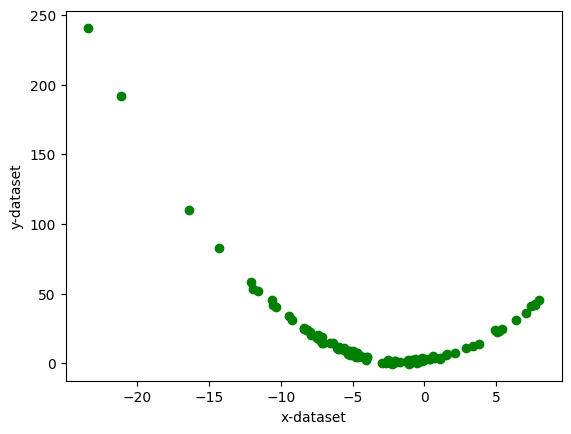

In [2]:
X=6*np.random.randn(100,1) -3
y=0.5 * X**2 + 1.5*X +2 +np.random.randn(100,1)
#Quadratic equation used    - ax**2 + b*x + c

plt.scatter(X,y,color='g')
plt.xlabel("x-dataset")
plt.ylabel("y-dataset")

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


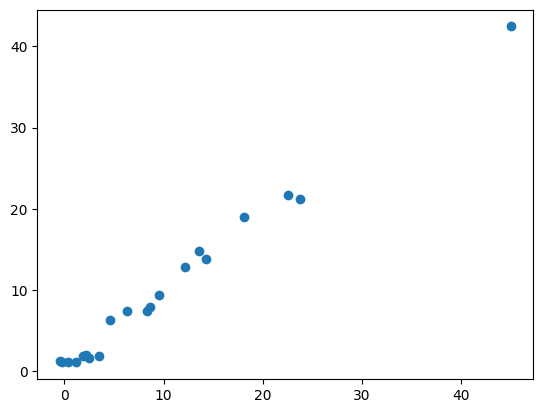

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

model=LinearRegression()

model.fit(X_train,y_train)

poly=PolynomialFeatures(degree=2,include_bias= True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

model.fit(X_train_poly,y_train)
y_pred_test=model.predict(X_test_poly)

plt.scatter(y_test,y_pred_test)




In [5]:
from sklearn.metrics import r2_score

score=r2_score(y_test,y_pred_test)
print(score)

0.9865663228766905


In [6]:
from sklearn.pipeline import Pipeline

In [28]:
def poly_regression(degree):
    X_new=np.linspace(-3,3,200).reshape(200,1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    line_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("line_reg",line_reg)       
    ])
    
    poly_regression.fit(X_train,y_train)
    
    y_pred_new=poly_regression.predict(X_new)
    
    
    plt.plot(X_new,y_pred_new, 'r', label='Degree' + str(degree) , linewidth=2)
    plt.scatter(X_train,y_train, color='b')
    plt.scatter(X_test,y_test, color='g')
    plt.legend(loc='upper left')
    plt.axis([-4,4,0,10])
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()
    

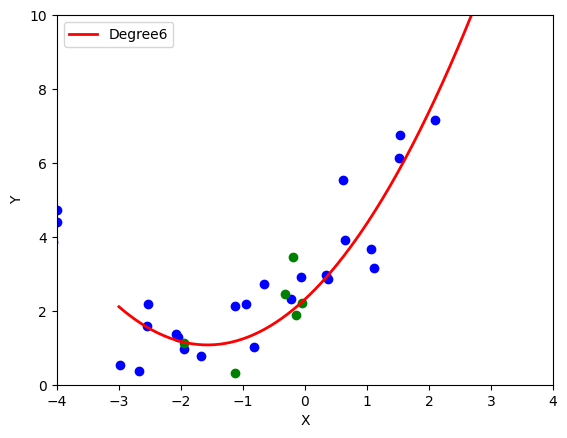

In [30]:
poly_regression(6)